# 01 — Análisis Exploratorio del Dataset (EDA)
## SmartCity IA — Módulo 1: Detección de actividad sospechosa en CCTV

**Dataset:** Videos editados (solo segmento del evento)
```
videos editados/
├── Stealing/     → Robo_Asalto
├── Assault/      → Robo_Asalto
├── Fighting/     → Pelea
├── Vandalism/    → Vandalismo
├── Merodeo/      → Merodeo
└── Normal/       → Normal
```

## 0. Configuración de rutas
⚠ **Editar `VIDEOS_DIR` y `FRAMES_DIR` según tu direccion.**

In [28]:
# ============================================================
# CONFIGURACIÓN — Edita estas rutas según tu equipo
# ============================================================
#VIDEOS_DIR       = r"C:\Users\victo\Downloads\videos editados"
VIDEOS_DIR       = r"D:\videos editados"
#FRAMES_DIR       = r"C:\Users\victo\Downloads\videos editados\frames"
FRAMES_DIR       = r"D:\videos editados\frames"
FRAMES_PER_VIDEO = 24 # frames por video# frames a extraer por video
IMG_SIZE         = 224   # tamaño de entrada para la CNN

import os
print("VIDEOS_DIR existe:", os.path.exists(VIDEOS_DIR))
print("Carpetas encontradas:", os.listdir(VIDEOS_DIR))

VIDEOS_DIR existe: True
Carpetas encontradas: ['Fighting', 'frames', 'Merodeo', 'Normal', 'Stealing', 'Vandalism', 'video_inventory.csv']


## 1. Imports

In [29]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
#from tqdm.notebook import tqdm
from tqdm import tqdm

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
print("Imports OK")

Imports OK


## 2. Mapeo de categorías → Clases del proyecto

In [30]:
# Mapeo de carpetas del dataset editado → 4 clases del proyecto
CATEGORY_MAP = {
    "Stealing"  : "Robo_Asalto",
    "Assault"   : "Robo_Asalto",
    "Fighting"  : "Pelea",
    "Vandalism" : "Vandalismo",
    "Normal"    : "Normal",
}

CLASS_COLORS = {
    "Normal"     : "#2ecc71",
    "Robo_Asalto": "#e74c3c",
    "Pelea"      : "#e67e22",
    "Vandalismo" : "#9b59b6",
}

print("Mapeo configurado (4 clases):")
for cat, cls in CATEGORY_MAP.items():
    print(f"  {cat:<12} → {cls}")

Mapeo configurado (4 clases):
  Stealing     → Robo_Asalto
  Assault      → Robo_Asalto
  Fighting     → Pelea
  Vandalism    → Vandalismo
  Normal       → Normal


## 3. Inventario de videos

In [31]:
records = []
root = Path(VIDEOS_DIR)

for carpeta in sorted(root.iterdir()):
    if not carpeta.is_dir():
        continue
    cat_name = carpeta.name
    mapped   = CATEGORY_MAP.get(cat_name, "Otro")
    if mapped == "Otro":
        print(f"⚠️  Carpeta sin mapeo: {cat_name}")
        continue
    for vf in carpeta.glob("*.mp4"):
        records.append({
            "path"         : str(vf),
            "filename"     : vf.name,
            "categoria"    : cat_name,
            "project_class": mapped,
        })

df_videos = pd.DataFrame(records)
print(f"Total videos encontrados: {len(df_videos)}")
print()
print("Videos por categoría:")
for cat, grp in df_videos.groupby("categoria"):
    cls = CATEGORY_MAP.get(cat)
    print(f"  {cat:<12} → {cls:<15}  ({len(grp)} videos)")

⚠️  Carpeta sin mapeo: frames
⚠️  Carpeta sin mapeo: Merodeo
Total videos encontrados: 33

Videos por categoría:
  Fighting     → Pelea            (9 videos)
  Normal       → Normal           (7 videos)
  Stealing     → Robo_Asalto      (3 videos)
  Vandalism    → Vandalismo       (14 videos)


## 4. Distribución de clases

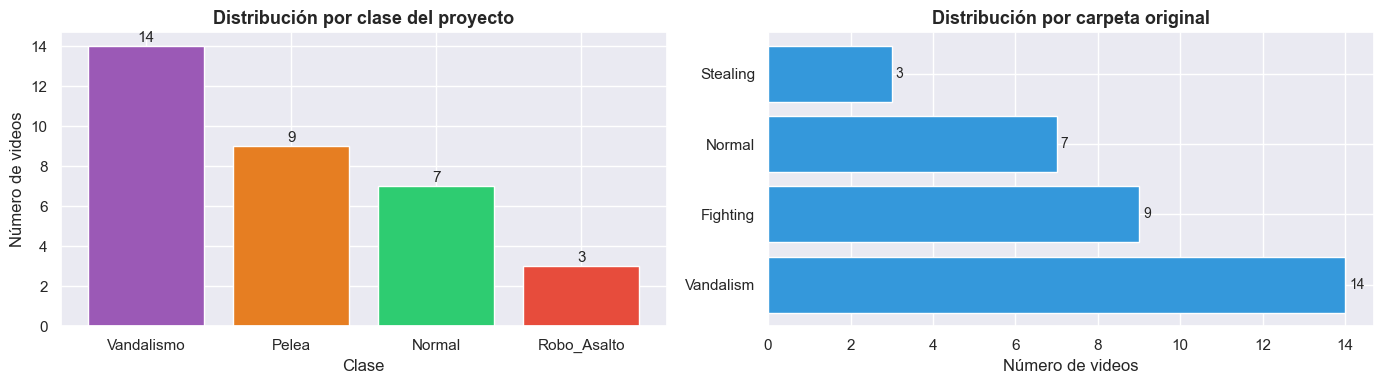

Resumen:
project_class
Vandalismo     14
Pelea           9
Normal          7
Robo_Asalto     3


In [32]:
class_counts = df_videos["project_class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Por clase del proyecto
colors = [CLASS_COLORS.get(c, "gray") for c in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Distribución por clase del proyecto", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de videos")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontsize=11)

# Por categoría original
cat_counts = df_videos["categoria"].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color="#3498db", edgecolor="white")
axes[1].set_title("Distribución por carpeta original", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Número de videos")
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 0.1, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resumen:")
print(class_counts.to_string())

## 5. Split Train / Test

Sin archivo de anotaciones externo, hacemos un split estratificado:
**80% train — 20% test** por clase.

In [33]:
# Split 80/20 POR VIDEO — garantiza que ningún frame de un video
# aparezca en train Y test al mismo tiempo (evita data leakage)
import random
random.seed(42)

train_rows = []
test_rows  = []

for cls in df_videos["project_class"].unique():
    subset = df_videos[df_videos["project_class"] == cls].copy()
    videos = subset["filename"].tolist()
    random.shuffle(videos)

    n_test   = max(1, int(len(videos) * 0.20))
    test_vids  = set(videos[:n_test])
    train_vids = set(videos[n_test:])

    test_rows.append(subset[subset["filename"].isin(test_vids)])
    train_rows.append(subset[subset["filename"].isin(train_vids)])

df_train = pd.concat(train_rows).reset_index(drop=True)
df_test  = pd.concat(test_rows).reset_index(drop=True)

df_videos["split"] = "train"
df_videos.loc[df_videos["filename"].isin(df_test["filename"]), "split"] = "test"

print(f"Train: {(df_videos.split=='train').sum()} videos")
print(f"Test : {(df_videos.split=='test').sum()} videos")
print()
print("Distribución por clase y split:")
print(df_videos.groupby(["project_class","split"]).size().unstack(fill_value=0).to_string())
print()
print("✅ Split por video — ningún video comparte frames entre train y test")

Train: 28 videos
Test : 5 videos

Distribución por clase y split:
split          test  train
project_class             
Normal            1      6
Pelea             1      8
Robo_Asalto       1      2
Vandalismo        2     12

✅ Split por video — ningún video comparte frames entre train y test


## 6. Análisis de duración de los videos editados

In [34]:
print("Leyendo metadatos de duración...")
durations = []
for _, row in tqdm(df_videos.iterrows(), total=len(df_videos)):
    try:
        cap = cv2.VideoCapture(row["path"])
        fps    = cap.get(cv2.CAP_PROP_FPS)
        frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()
        dur = frames / fps if fps > 0 else 0
    except:
        dur = 0
    durations.append(dur)

df_videos["duration_sec"] = durations
df_videos["duration_min"] = df_videos["duration_sec"] / 60

print(f"Duración promedio: {df_videos['duration_sec'].mean():.1f}s")
print(f"Duración mínima  : {df_videos['duration_sec'].min():.1f}s")
print(f"Duración máxima  : {df_videos['duration_sec'].max():.1f}s")

Leyendo metadatos de duración...


100%|██████████| 33/33 [00:03<00:00, 10.80it/s]

Duración promedio: 42.3s
Duración mínima  : 3.1s
Duración máxima  : 307.0s


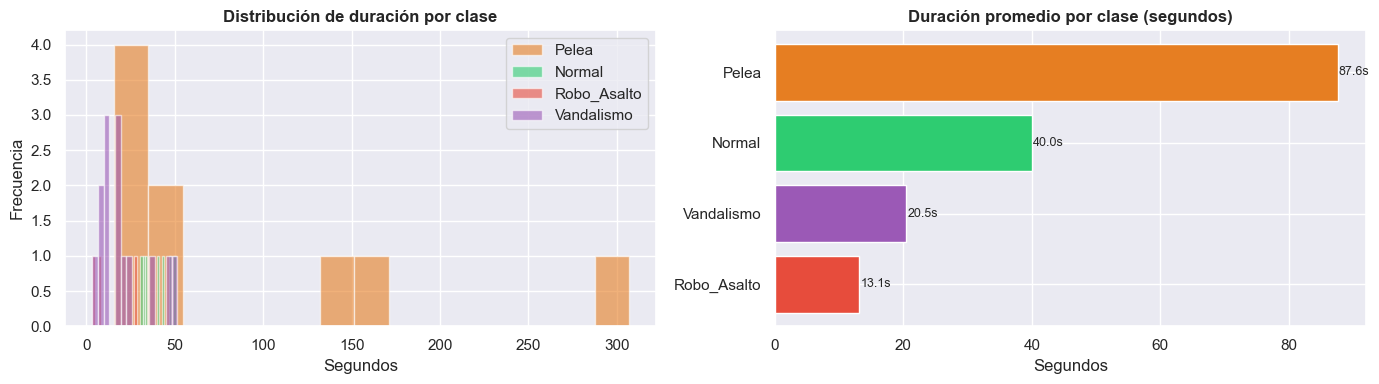

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de duraciones por clase
for cls in df_videos["project_class"].unique():
    subset = df_videos[df_videos["project_class"] == cls]["duration_sec"]
    axes[0].hist(subset, alpha=0.6, label=cls, bins=15,
                 color=CLASS_COLORS.get(cls, "gray"))
axes[0].set_title("Distribución de duración por clase", fontweight="bold")
axes[0].set_xlabel("Segundos")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Duración promedio por clase
dur_media = df_videos.groupby("project_class")["duration_sec"].mean().sort_values()
colors_bar = [CLASS_COLORS.get(c,"gray") for c in dur_media.index]
axes[1].barh(dur_media.index, dur_media.values, color=colors_bar, edgecolor="white")
axes[1].set_title("Duración promedio por clase (segundos)", fontweight="bold")
axes[1].set_xlabel("Segundos")
for i, v in enumerate(dur_media.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}s", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("duracion_videos.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Vista previa de un frame por clase

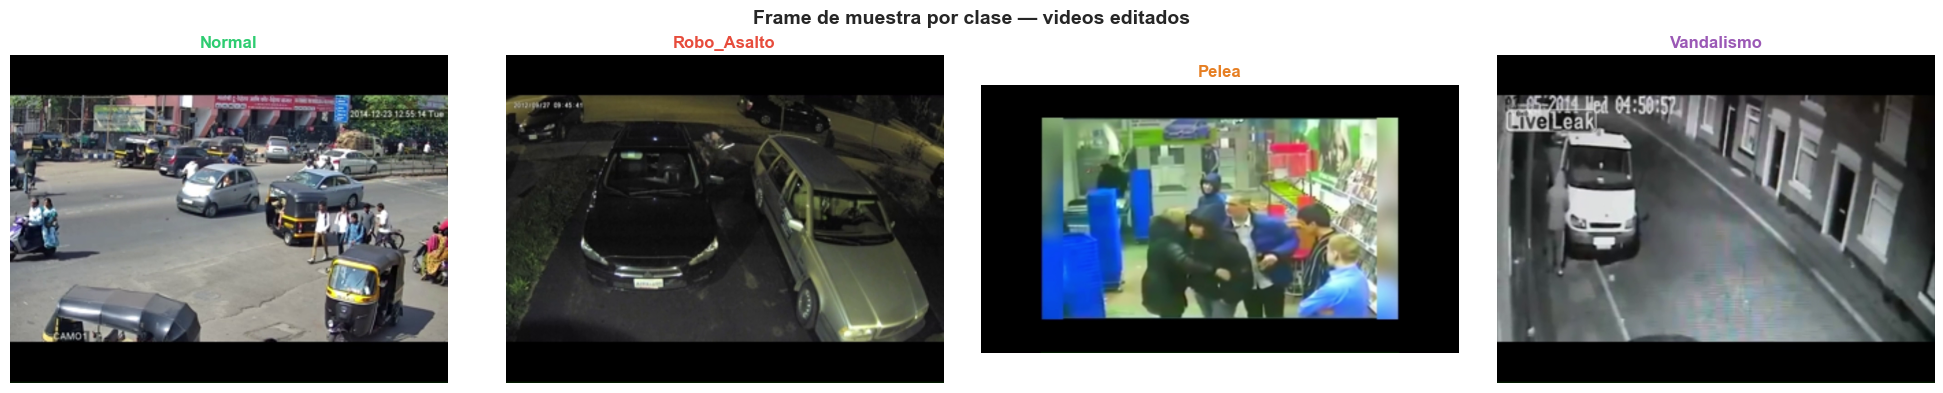

In [36]:
clases_orden = ["Normal", "Robo_Asalto", "Pelea", "Vandalismo"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Frame de muestra por clase — videos editados", fontsize=14, fontweight="bold")

for ax, cls in zip(axes, clases_orden):
    subset = df_videos[df_videos["project_class"] == cls]
    if len(subset) == 0:
        ax.set_title(f"{cls}\n(sin videos)")
        ax.axis("off")
        continue
    frame = None
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        cap = cv2.VideoCapture(row["path"])
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total_f // 2)  # frame del medio
        ret, f = cap.read()
        cap.release()
        if ret:
            frame = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
            break
    if frame is not None:
        ax.imshow(frame)
        ax.set_title(cls, fontweight="bold", color=CLASS_COLORS.get(cls, "black"))
    else:
        ax.set_title(f"{cls}\n(no legible)")
    ax.axis("off")

plt.tight_layout()
plt.savefig("muestra_frames.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Resumen del dataset

In [37]:
print("=" * 55)
print("RESUMEN DEL DATASET")
print("=" * 55)
print(f"Total videos : {len(df_videos)}")
print(f"  Train      : {(df_videos.split=='train').sum()}")
print(f"  Test       : {(df_videos.split=='test').sum()}")
print()
print("Distribución por clase (train):")
train_dist = df_videos[df_videos.split=="train"]["project_class"].value_counts()
for cls, cnt in train_dist.items():
    pct = cnt / train_dist.sum() * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls:<15} {cnt:>4} videos  {pct:>5.1f}%  {bar}")
print()
imbalance = train_dist.max() / train_dist.min()
print(f"Ratio de desbalance: {imbalance:.1f}x")
if imbalance > 3:
    print("⚠️  Dataset desbalanceado — se usará class_weight en entrenamiento")
else:
    print("✅ Balance aceptable")

RESUMEN DEL DATASET
Total videos : 33
  Train      : 28
  Test       : 5

Distribución por clase (train):
  Vandalismo        12 videos   42.9%  █████████████████████
  Pelea              8 videos   28.6%  ██████████████
  Normal             6 videos   21.4%  ██████████
  Robo_Asalto        2 videos    7.1%  ███

Ratio de desbalance: 6.0x
⚠️  Dataset desbalanceado — se usará class_weight en entrenamiento


## 9. Extracción de frames con OpenCV

Extraemos `FRAMES_PER_VIDEO` frames uniformemente espaciados de cada video.
⏱️ **Solo se ejecuta una vez** — si el frame ya existe lo reutiliza.

In [38]:
import shutil

# Borrar frames anteriores si existen
if os.path.exists(FRAMES_DIR):
    shutil.rmtree(FRAMES_DIR)
    print(f"Carpeta eliminada: {FRAMES_DIR}")
os.makedirs(FRAMES_DIR, exist_ok=True)
print(f"Carpeta creada   : {FRAMES_DIR}")

Carpeta eliminada: D:\videos editados\frames
Carpeta creada   : D:\videos editados\frames


In [39]:
frame_records = []
skipped = 0

for _, row in tqdm(df_videos.iterrows(), total=len(df_videos),
                   desc=f"Extrayendo {FRAMES_PER_VIDEO} frames/video"):

    out_dir = Path(FRAMES_DIR) / row["split"] / row["project_class"]
    out_dir.mkdir(parents=True, exist_ok=True)
    video_stem = Path(row["path"]).stem

    # Reutilizar si ya existen
    existing = list(out_dir.glob(f"{video_stem}_*.jpg"))
    if len(existing) >= FRAMES_PER_VIDEO:
        for p in existing:
            frame_records.append({
                "frame_path"   : str(p),
                "project_class": row["project_class"],
                "split"        : row["split"],
            })
        continue

    cap = cv2.VideoCapture(row["path"])
    if not cap.isOpened():
        skipped += 1
        continue

    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = (np.linspace(0, total_f - 1, FRAMES_PER_VIDEO, dtype=int)
               if total_f >= FRAMES_PER_VIDEO else list(range(total_f)))

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        out_path = out_dir / f"{video_stem}_f{i:02d}.jpg"
        cv2.imwrite(str(out_path), frame)
        frame_records.append({
            "frame_path"   : str(out_path),
            "project_class": row["project_class"],
            "split"        : row["split"],
        })
    cap.release()

df_frames = pd.DataFrame(frame_records)
print(f"\nVideos no legibles : {skipped}")
print(f"Total frames extraídos: {len(df_frames):,}")
print()
print(df_frames.groupby(["split","project_class"]).size().unstack(fill_value=0))

Extrayendo 24 frames/video: 100%|██████████| 33/33 [01:30<00:00,  2.73s/it]


Videos no legibles : 0
Total frames extraídos: 792

project_class  Normal  Pelea  Robo_Asalto  Vandalismo
split                                                
test               24     24           24          48
train             144    192           48         288


## 10. Guardar inventario

In [40]:
# Guardar inventario junto a los videos
csv_out = os.path.join(VIDEOS_DIR, "video_inventory.csv")
df_videos.to_csv(csv_out, index=False)
print(f"Inventario guardado: {csv_out}")

# Guardar índice de frames
index_path = os.path.join(FRAMES_DIR, "frames_index.csv")
df_frames.to_csv(index_path, index=False)
print(f"Índice frames  guardado: {index_path}")
print()
print(f"Train: {len(df_frames[df_frames.split=='train']):,} frames")
print(f"Test : {len(df_frames[df_frames.split=='test']):,} frames")
print()
print("✅ EDA completado. Abre 02_CNN_CCTV_pytorch.ipynb y ejecuta desde cero.")

Inventario guardado: D:\videos editados\video_inventory.csv
Índice frames  guardado: D:\videos editados\frames\frames_index.csv

Train: 672 frames
Test : 120 frames

✅ EDA completado. Abre 02_CNN_CCTV_pytorch.ipynb y ejecuta desde cero.
